Gradients are one of the cornerstones of training a neural network. We will spend several chapters up front with this concept before touching a neural network with the ultimate goal of understanding what a gradient is.

It's ok if you've never heard of a gradient. **It's essentially a slope, so for now just assume that a gradient is a slope.** I will be using slopes and gradients interchangeably here.

## Constants

Let's start with the function $f(x) = 1$. There is nothing special about this function; it's just simple and a good place to start. If we plot this functions we see a horizontal line at $y=1$.

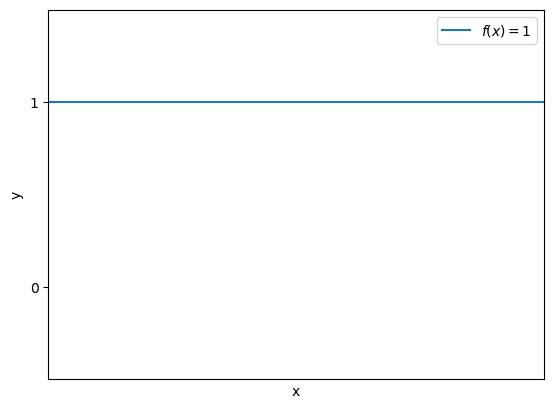

In [8]:
#| echo: false
import matplotlib.pyplot as plt

plt.axhline(y=1, label=r'$f(x) = 1$')
plt.ylim(-0.5, 1.5)
plt.xticks([])
plt.yticks([0, 1])
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

The slope (or gradient) of this line is $0$. This means that as $x$ changes, $y$ remains constant. This is true for any constant value; the slope of $f(x) = 5$ and $f(x) = 1$ is the same. Let's formalize this definition.

> The gradient of a constant value is $0$.

We can see this by plotting the change in $y$ with respect to $x$.

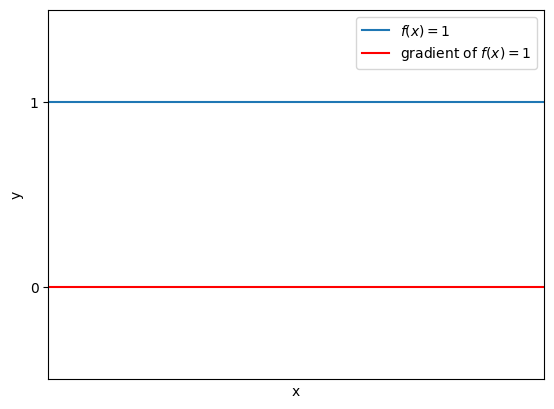

In [9]:
#| echo: false
plt.axhline(y=1, label='$f(x) = 1$')
plt.axhline(y=0, color='red', label='gradient of $f(x) = 1$')
plt.ylim(-0.5, 1.5)
plt.xticks([])
plt.yticks([0, 1])
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Our first code

It's not much, but we have enough information to start writing code. Let's define a file `torchless/base/constant.py` which implements a constant value and it's gradient.[There are instructions to create the `torchless` project in the [Introduction](#sec-setup-project).]{.aside} We use a `@property` decorator to emphasize that the data should be read only because it is intended to be constant.

In [10]:
#| filename: torchless/base/constant.py
class Constant:

    def __init__(self, data):
        self._data = data

    @property
    def data(self):
        return self._data

    def compute_grad(self):
        return 0

## Variables

Now, we'll take it to the next level and look at the function $f(x) = x$ and it's associated plot.

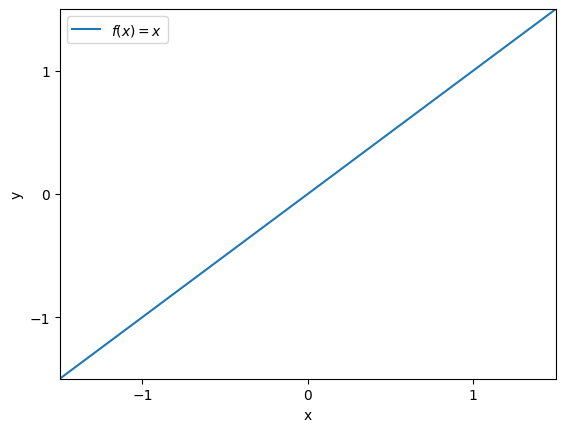

In [12]:
#| echo: false
plt.plot([-2, 2], [-2, 2], label=r'$f(x) = x$')
plt.ylim(-1.5, 1.5)
plt.xlim(-1.5, 1.5)
plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

The gradient of this line is $1$. This means that as $x$ changes, $y$ changes equally. Let's refine our definition of a gradient.

> The gradient of a constant value is $0$ and the gradient of a variable value is 1.

We can see this by plotting the change in $y$ with respect to $x$.

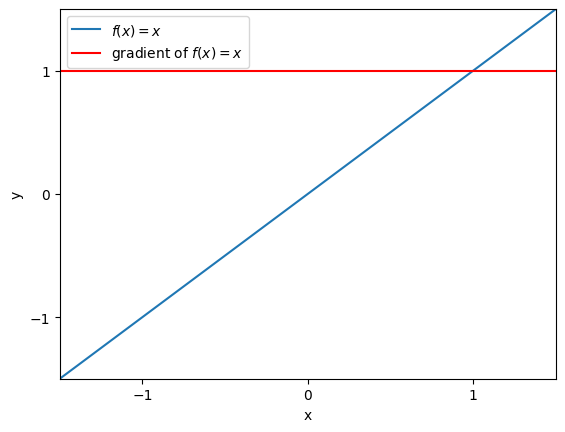

In [13]:
#| echo: false
plt.plot([-2, 2], [-2, 2], label=r'$f(x) = x$')
plt.axhline(y=1, color='red', label='gradient of $f(x) = x$')
plt.ylim(-1.5, 1.5)
plt.xlim(-1.5, 1.5)
plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Our second code

You probably see where this is going. While this class will be simple, we will be using it a lot as it will define the values that make up neural networks.

In [14]:
#| filename: torchless/base/value.py
class Value:

    def __init__(self, data):
        self.data = data

    def compute_grad(self):
        return 1